# Week 3 — Batch PDF Processing + Regex Baseline Evaluation
**Continues directly from Week 2**

```
Week 2                            Week 3 (This Notebook)
─────────────────────────         ──────────────────────────────────────
Single PDF path (hardcoded)  →    Folder of PDFs  (all .pdf files)
clean_text()                 →    Reused unchanged
segment_into_clauses()       →    Reused unchanged
clause_categories dict       →    Reused unchanged
classify_clause()            →    Reused unchanged
SpaCy NER                    →    Reused unchanged
Single JSON file             →    Per-doc JSON  +  corpus_clauses.json
                                       │
                                       ▼
                                  Regex Baseline
                                  (scored multi-pattern, Week2-aligned)
                                       │
                                       ▼
                                  Ground Truth  (local NLI, no API key)
                                       │
                                       ▼
                                  Metrics: F1 / Precision / Recall /
                                  Accuracy + Confusion Matrix
```

## 0. Install Dependencies

In [1]:
import sys
!{sys.executable} -m pip install -q pypdf spacy transformers scikit-learn torch pandas matplotlib seaborn tqdm
!{sys.executable} -m spacy download en_core_web_sm -q
print('All dependencies ready.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.7/333.7 kB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 77.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
All dependencies ready.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Configuration

In [4]:
import os, re, json, time
from pathlib import Path
from collections import defaultdict
import spacy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.metrics import (
    classification_report, f1_score, accuracy_score,
    precision_score, recall_score, confusion_matrix,
)
from transformers import pipeline as hf_pipeline

# ── Set your paths here ───────────────────────────────────────────────────────
PDF_FOLDER = '/content/drive/MyDrive/Colab Notebooks/project'   # folder containing your .pdf files
OUTPUT_DIR = '/content/drive/MyDrive/Colab Notebooks/project/outputs'      # where JSON + plots are saved
# ─────────────────────────────────────────────────────────────────────────────

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
pdf_files = sorted(Path(PDF_FOLDER).glob('*.pdf'))
print(f'Found {len(pdf_files)} PDF(s) in "{PDF_FOLDER}":')
for p in pdf_files:
    print(f'  {p.name}')
if not pdf_files:
    print('No PDFs found — run the next cell to create demo PDFs, or add real PDFs to the folder.')

Found 5 PDF(s) in "/content/drive/MyDrive/Colab Notebooks/project":
  AI Powered Legal Contract Risk Assessment (1).pdf
  Law_Insider_american-express-receivables-financing-corp-iii-llc_underwriting-agreement-american-express-credit-account-master-trust-1500000000-class-a-series-20_Filed_07-05-2025_Contract.pdf
  Law_Insider_citigroup-inc_contract_Filed_07-05-2025_Contract.pdf
  Law_Insider_fidelity-salem-street-trust_general-distribution-agreement-between-fidelity-salem-street-trust-and_Filed_10-04-2025_Contract.pdf
  Law_Insider_morgan-stanley_investor-agreement-by-and-between-morgan-stanley-and-investor-dated-as-of-october-13-2008_Filed_17-10-2008_Contract.pdf


In [5]:
# ── DEMO: generate synthetic PDFs when folder is empty ────────────────────────
# Skip this cell if you already have real PDFs in PDF_FOLDER.
if not pdf_files:
    try:
        from fpdf import FPDF
    except ImportError:
        !{sys.executable} -m pip install -q fpdf2
        from fpdf import FPDF

    DEMO = {
        'affirm_merchant_agreement.pdf': [
            'MERCHANT AGREEMENT — entered into between Affirm, Inc. and Merchant.',
            '1. PAYMENT TERMS. Merchant shall pay all applicable processing fees per Schedule A. Settlement occurs within two (2) business days. BNPL MDR is 2.9% plus $0.30 per transaction. Late payments accrue interest at 1.5% per month.',
            '2. TERM AND TERMINATION. Either party may terminate upon ninety (90) days written notice. Affirm may terminate immediately for AML violations or fraudulent activity.',
            '3. CONFIDENTIALITY. Each party shall maintain strict confidentiality of non-public financial data, transaction records, and pricing. KYC documentation shall not be disclosed except as required by court order.',
            '4. LIMITATION OF LIABILITY. In no event shall Affirm be liable for indirect or consequential damages. Aggregate liability shall not exceed fees paid in the preceding twelve months.',
            '5. OBLIGATIONS. Merchant must implement PCI-DSS compliant environment and provide annual AOC certification within thirty (30) days after audit.',
            '6. GOVERNING LAW. This Agreement is governed by the laws of the State of California. Disputes resolved by arbitration in San Francisco.',
            '7. REPRESENTATIONS AND WARRANTIES. Each party warrants full authority to enter this Agreement. Affirm warrants its platform is PCI-DSS Level 1 certified.',
            '8. INTELLECTUAL PROPERTY. Affirm retains all rights in its platform and trademarks. Merchant receives a limited non-exclusive license to use the Affirm API.',
            '9. ENTIRE AGREEMENT. This Agreement supersedes all prior oral and written agreements between the parties.',
        ],
        'lending_club_loan_agreement.pdf': [
            'LOAN AGREEMENT — LendingClub Bank and Borrower.',
            '1. PAYMENT. Borrower shall repay $50,000 in 36 monthly installments at 8.5% annual interest rate via ACH on the 15th of each month.',
            '2. TERMINATION. Lender may accelerate all outstanding obligations upon Borrower insolvency or bankruptcy filing.',
            '3. CONFIDENTIALITY. LendingClub shall not disclose borrower financial data except as required by applicable law or regulatory directive.',
            '4. LIMITATION OF LIABILITY. LendingClub disclaims all implied warranties regarding credit decisioning algorithms. Force majeure events exclude liability.',
            '5. BORROWER OBLIGATIONS. Borrower shall maintain DSCR of 1.25x and provide quarterly financial statements within 45 days of quarter-end.',
            '6. REPRESENTATIONS. Borrower represents that all financial statements are accurate. Borrower warrants no material litigation is pending.',
            '7. GOVERNING LAW. Agreement governed by federal law and laws of the State of Utah. Disputes submitted to courts of Salt Lake City.',
            '8. ASSIGNMENT. Borrower may not assign any rights without prior written consent of LendingClub.',
        ],
        'square_payment_services.pdf': [
            'PAYMENT SERVICES AGREEMENT — Square, Inc. and Merchant.',
            '1. FEES. Square charges 2.6% plus $0.10 per card-present transaction. Funds settle within one to two business days. Foreign currency conversion fees apply.',
            '2. TERMINATION. Square may suspend accounts immediately for chargeback ratios exceeding 1% of monthly volume. Either party may terminate with 30 days notice.',
            '3. CONFIDENTIALITY. Cardholder data and PAN information are Confidential Information subject to PCI-DSS. Square shall not sell merchant financial data.',
            '4. LIMITATION OF LIABILITY. Aggregate liability is capped at fees paid in the prior 12 months. Square is not liable for lost profits or business interruption.',
            '5. OBLIGATIONS. Merchant shall not process prohibited business types and must ensure EMV compliance. Fraud must be reported within 24 hours.',
            '6. INTELLECTUAL PROPERTY. The Square mark and POS software are proprietary to Square. Merchant receives a revocable license.',
            '7. AMENDMENTS. Square may modify terms with 30 days prior notice. Continued use constitutes acceptance of amended terms.',
        ],
    }

    Path(PDF_FOLDER).mkdir(parents=True, exist_ok=True)
    for fname, paras in DEMO.items():
        pdf = FPDF(); pdf.add_page(); pdf.set_font('Helvetica', size=10)
        for p in paras:
            pdf.multi_cell(0, 6, p); pdf.ln(3)
        pdf.output(str(Path(PDF_FOLDER) / fname))
        print(f'  Created: {fname}')

    pdf_files = sorted(Path(PDF_FOLDER).glob('*.pdf'))
    print(f'Demo corpus ready: {len(pdf_files)} PDFs')

## 2. Week 2 Functions — Reused Unchanged

In [6]:
# clean_text — identical to Week 2
def clean_text(text):
    cleaned = re.sub(r'\uf0a0', ' ', text)
    cleaned = re.sub(r'\u00a0', ' ', cleaned)
    cleaned = re.sub(r'\s+',    ' ', cleaned)
    return cleaned.strip()

# segment_into_clauses — identical to Week 2
def segment_into_clauses(text):
    clauses = re.split(r'(?<=[.!?]) +|\n+|; +', text)
    return [c.strip() for c in clauses if c.strip()]

# clause_categories — identical to Week 2
clause_categories = {
    'Parties':                       ['merchant','company','party','agreement','affiliate','customer','supplier','provider','user','seller','buyer'],
    'Term and Termination':          ['term','terminate','termination','expiration','renewal','effective date','commencement date','end date','duration','period'],
    'Confidentiality':               ['confidential','disclosure','secret','proprietary','non-disclosure','nondisclosure','confidential information'],
    'Governing Law':                 ['governing law','jurisdiction','applicable law','venue','dispute resolution','arbitration','court','state','country'],
    'Payment':                       ['payment','fee','charge','invoice','remuneration','compensation','price','currency','due date','tax','late payment'],
    'Indemnification':               ['indemnify','indemnification','hold harmless','damages','losses','claims','liabilities'],
    'Limitation of Liability':       ['limit liability','limitation of liability','maximum liability','exclude liability','indirect damages','consequential damages'],
    'Representations and Warranties':['represent','warrant','representation','warranty','guarantee','covenant','accuracy','truthfulness'],
    'Intellectual Property':         ['intellectual property','patent','trademark','copyright','license','licence','infringement','ownership','rights'],
    'Force Majeure':                 ['force majeure','act of god','unforeseeable','circumstances','event beyond control','delay','failure to perform'],
    'Notices':                       ['notice','address','writing','mail','email','fax','delivery'],
    'Assignment':                    ['assign','assignment','transfer','delegate'],
    'Severability':                  ['severable','invalid','unenforceable','void','provision','clause'],
    'Amendments':                    ['amend','modify','change','alteration','in writing'],
    'Entire Agreement':              ['entire agreement','supersedes','prior agreements','oral agreements','understanding'],
    'General Provisions':            [],
}

# classify_clause — identical to Week 2
def classify_clause(clause_text, categories):
    lower = clause_text.lower()
    best, max_matches = 'General Provisions', 0
    for cat, kws in categories.items():
        if cat == 'General Provisions': continue
        m = sum(1 for kw in kws if kw in lower)
        if m > max_matches:
            max_matches, best = m, cat
    return best

print('Week 2 functions loaded (clean_text, segment_into_clauses, classify_clause, clause_categories).')

Week 2 functions loaded (clean_text, segment_into_clauses, classify_clause, clause_categories).


## 3. NEW — Batch PDF Reader

In [7]:
from pypdf import PdfReader

nlp = spacy.load('en_core_web_sm')

def extract_text_from_pdf(path):
    raw = ''
    with open(path, 'rb') as f:
        for page in PdfReader(f).pages:
            t = page.extract_text()
            if t: raw += t + '\n'
    return raw

def run_ner(clauses):
    return [{'clause_text': c,
             'entities': [{'text': e.text, 'label': e.label_,
                           'start_char': e.start_char, 'end_char': e.end_char}
                          for e in nlp(c).ents]}
            for c in clauses]

def process_pdf(path):
    raw      = extract_text_from_pdf(path)
    cleaned  = clean_text(raw)
    clauses  = segment_into_clauses(cleaned)
    ner      = run_ner(clauses)
    combined = [{'clause_id': i, 'clause_text': c,
                 'category': classify_clause(c, clause_categories),
                 'entities': ner[i]['entities']}
                for i, c in enumerate(clauses)]
    return {'source_file': path.name, 'total_clauses': len(clauses), 'clauses': combined}

print('Batch PDF processor ready.')

Batch PDF processor ready.


In [8]:
corpus_docs, doc_stats = [], []
print(f'Processing {len(pdf_files)} PDF(s)...\n')

for path in tqdm(pdf_files, desc='PDFs'):
    t0  = time.time()
    doc = process_pdf(path)
    t1  = round(time.time() - t0, 2)
    corpus_docs.append(doc)

    counts = defaultdict(int)
    for c in doc['clauses']: counts[c['category']] += 1
    doc_stats.append({'file': path.name, 'clauses': doc['total_clauses'], 'seconds': t1, **dict(counts)})

    # save per-document JSON (same structure as Week 2)
    out = Path(OUTPUT_DIR) / f'{path.stem}_parsed.json'
    json.dump(doc, open(out, 'w'), indent=4)
    print(f'  {path.name:45s}  {doc["total_clauses"]:4d} clauses  {t1}s  ->  {out.name}')

# merged corpus JSON
corpus_path = Path(OUTPUT_DIR) / 'corpus_clauses.json'
json.dump(corpus_docs, open(corpus_path, 'w'), indent=4)
total = sum(d['total_clauses'] for d in corpus_docs)
print(f'\nCorpus saved: {corpus_path}  ({total} total clauses)')

Processing 5 PDF(s)...



PDFs:   0%|          | 0/5 [00:00<?, ?it/s]

  AI Powered Legal Contract Risk Assessment (1).pdf     6 clauses  0.68s  ->  AI Powered Legal Contract Risk Assessment (1)_parsed.json
  Law_Insider_american-express-receivables-financing-corp-iii-llc_underwriting-agreement-american-express-credit-account-master-trust-1500000000-class-a-series-20_Filed_07-05-2025_Contract.pdf   293 clauses  7.89s  ->  Law_Insider_american-express-receivables-financing-corp-iii-llc_underwriting-agreement-american-express-credit-account-master-trust-1500000000-class-a-series-20_Filed_07-05-2025_Contract_parsed.json
  Law_Insider_citigroup-inc_contract_Filed_07-05-2025_Contract.pdf   172 clauses  3.46s  ->  Law_Insider_citigroup-inc_contract_Filed_07-05-2025_Contract_parsed.json
  Law_Insider_fidelity-salem-street-trust_general-distribution-agreement-between-fidelity-salem-street-trust-and_Filed_10-04-2025_Contract.pdf    72 clauses  2.24s  ->  Law_Insider_fidelity-salem-street-trust_general-distribution-agreement-between-fidelity-salem-street-trust-and_

In [9]:
stats_df = pd.DataFrame(doc_stats)
print('=== Per-Document Summary ===')
print(stats_df[['file','clauses','seconds']].to_string(index=False))

all_clauses = [c for d in corpus_docs for c in d['clauses']]
cat_dist    = pd.Series([c['category'] for c in all_clauses])
print(f'\n=== Corpus Category Distribution (total {len(all_clauses)}) ===')
print(cat_dist.value_counts().to_string())

=== Per-Document Summary ===
                                                                                                                                                                                          file  clauses  seconds
                                                                                                                                             AI Powered Legal Contract Risk Assessment (1).pdf        6     0.68
Law_Insider_american-express-receivables-financing-corp-iii-llc_underwriting-agreement-american-express-credit-account-master-trust-1500000000-class-a-series-20_Filed_07-05-2025_Contract.pdf      293     7.89
                                                                                                                              Law_Insider_citigroup-inc_contract_Filed_07-05-2025_Contract.pdf      172     3.46
                                                  Law_Insider_fidelity-salem-street-trust_general-distribution-agreement-between-fideli

## 4. Load corpus_clauses.json → DataFrame

In [10]:
with open(corpus_path) as f:
    loaded = json.load(f)

rows = []
for doc in loaded:
    for c in doc['clauses']:
        rows.append({'source_file': doc['source_file'],
                     'clause_id':   c['clause_id'],
                     'clause_text': c['clause_text'],
                     'week2_category': c['category']})

df = pd.DataFrame(rows)
df = df[df['clause_text'].str.len() >= 40].reset_index(drop=True)
print(f'DataFrame: {df.shape[0]} clauses from {df["source_file"].nunique()} file(s)')
print(df[['source_file','week2_category']].value_counts().head(20))

DataFrame: 632 clauses from 5 file(s)
source_file                                                                                                                                                                                     week2_category                
Law_Insider_morgan-stanley_investor-agreement-by-and-between-morgan-stanley-and-investor-dated-as-of-october-13-2008_Filed_17-10-2008_Contract.pdf                                              Parties                           95
Law_Insider_american-express-receivables-financing-corp-iii-llc_underwriting-agreement-american-express-credit-account-master-trust-1500000000-class-a-series-20_Filed_07-05-2025_Contract.pdf  Parties                           88
Law_Insider_citigroup-inc_contract_Filed_07-05-2025_Contract.pdf                                                                                                                                General Provisions                43
Law_Insider_american-express-receivables-financing-c

## 5. Enhanced Regex Baseline

Same 16-category taxonomy as Week 2, but uses scored `re.findall` instead of
plain substring matching — picks the label with the **most regex hits**.

| Aspect | Week 2 `classify_clause` | Week 3 regex baseline |
|---|---|---|
| Match method | `keyword in text` | `re.findall(pattern)` |
| Winner | First-hit | Most-hits (scored) |
| Boundary handling | None | `\b` word boundaries |
| Coverage | ~10 keywords/class | ~15–20 patterns/class |

In [11]:
REGEX_PATTERNS = {
    'Parties': r'(\bpart(?:y|ies)\b|\bmerchant\b|\bsupplier\b|\bprovider\b|\bcustomer\b|\bseller\b|\bbuyer\b|\baffiliate\b|\bhereinafter\b|\brecitals\b|\bentered\s+into\b)',
    'Term and Termination': r'(\bterminat[ei]\w*\b|\bterm\s+of\b|\bterm\s+and\b|\bexpir\w+\b|\brenewal\b|\bcancel\w*\b|\beffective\s+date\b|\bcommencement\b|\bwithout\s+cause\b|\bfor\s+cause\b|\bwind\s*down\b|\baccelerat\w+\b|\bsuspend\w*\b)',
    'Confidentiality': r'(\bconfidential\w*\b|\bnon.?disclosure\b|\bproprietary\b|\btrade\s+secret\b|\bNDA\b|\bprivacy\b|\bdisclose\b|\bnot\s+disclose\b|\bsecrecy\b|\bKYC\b|\bAML\b|\bSAR\b)',
    'Governing Law': r'(\bgoverning\s+law\b|\bjurisdiction\b|\bapplicable\s+law\b|\bvenue\b|\bdispute\s+resolution\b|\barbitration\b|\bgoverned\s+by\b|\bstate\s+of\s+\w+\b|\bchoice\s+of\s+law\b|\bfederal\s+courts?\b)',
    'Payment': r'(\bpayment\b|\bfee[s]?\b|\binvoice\b|\bamount\s+payable\b|\bdisbursement\b|\bdue\s+date\b|\bwire\s+transfer\b|\bACH\b|\bprocessing\s+fee\b|\bsettle[sd]?\b|\bMDR\b|\binterchange\b|\bchargeback\b|\bcurrency\b)',
    'Indemnification': r'(\bindemnif\w+\b|\bindemnit\w+\b|\bhold\s+harmless\b|\bdefend\b|\bthird.?party\s+claim\b|\blosses\b|\bfines\b|\bpenalt\w+\b)',
    'Limitation of Liability': r'(\blimit\w*\s+liabilit\w+\b|\bliabilit\w+\s+cap\b|\bmaximum\s+liabilit\w+\b|\bindirect\s+damages\b|\bconsequential\s+damages\b|\bpunitive\b|\bin\s+no\s+event\s+shall\b|\bnot\s+exceed\b|\bdisclaim\w*\b)',
    'Representations and Warranties': r'(\brepresent\w*\b|\bwarrant\w*\b|\bwarranties\b|\bguarantee[sd]?\b|\bcovenant[s]?\b|\baccuracy\b|\bhereby\s+represent\b|\bhereby\s+warrant\b)',
    'Intellectual Property': r'(\bintellectual\s+property\b|\bpatent[s]?\b|\btrademark[s]?\b|\bcopyright[s]?\b|\blicen[sc]e[sd]?\b|\binfringement\b|\bownership\s+of\b|\broyalt\w+\b|\bsource\s+code\b)',
    'Force Majeure': r'(\bforce\s+majeure\b|\bact\s+of\s+god\b|\bunforeseeable\b|\bbeyond\s+.{0,20}control\b|\bfailure\s+to\s+perform\b|\bpandemic\b|\bgovernment\s+action\b)',
    'Notices': r'(\bnotice[s]?\b|\bwritten\s+notice\b|\bnotif\w+\b|\baddressed\s+to\b|\bcertified\s+mail\b|\bemail\s+to\b|\bregistered\s+mail\b)',
    'Assignment': r'(\bassign\w*\b|\btransfer\w*\b|\bdelegate[sd]?\b|\bsuccessor[s]?\b|\bnovation\b)',
    'Severability': r'(\bseverab\w+\b|\bsevered\b|\binvalid\b|\bunenforceable\b|\bvoid\b|\bremaining\s+provision\b)',
    'Amendments': r'(\bamend\w*\b|\bmodif\w+\b|\balteration\b|\bsupplemental\b|\baddendum\b|\bwritten\s+consent\b)',
    'Entire Agreement': r'(\bentire\s+agreement\b|\bsupersede[sd]?\b|\bprior\s+agreement\b|\boral\s+agreement\b|\bmerger\s+clause\b|\bintegration\s+clause\b)',
    'General Provisions': r'(\bgene?ral\s+provision\b|\bmiscellaneous\b)',
}

def regex_baseline_classify(text):
    scores = {lbl: len(re.findall(pat, text, re.IGNORECASE))
              for lbl, pat in REGEX_PATTERNS.items()}
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else 'General Provisions'

# Smoke test
smoke = [
    ('Merchant shall pay all processing fees within 30 days of invoice.',       'Payment'),
    ('Either party may terminate this agreement upon 90 days written notice.',   'Term and Termination'),
    ('In no event shall Affirm be liable for consequential or indirect damages.','Limitation of Liability'),
    ('All proprietary information shall remain confidential; KYC data protected.','Confidentiality'),
    ('This Agreement is governed by the laws of the State of California.',        'Governing Law'),
    ('This Agreement supersedes all prior oral and written understandings.',       'Entire Agreement'),
]
print(f'{"Clause (truncated)":55s}  {"Expected":30s}  {"Predicted":30s}  OK?')
print('-'*125)
for text, expected in smoke:
    pred  = regex_baseline_classify(text)
    match = '✓' if pred == expected else '✗'
    print(f'{text[:54]:55s}  {expected:30s}  {pred:30s}  {match}')

Clause (truncated)                                       Expected                        Predicted                       OK?
-----------------------------------------------------------------------------------------------------------------------------
Merchant shall pay all processing fees within 30 days    Payment                         Payment                         ✓
Either party may terminate this agreement upon 90 days   Term and Termination            Parties                         ✗
In no event shall Affirm be liable for consequential o   Limitation of Liability         Limitation of Liability         ✓
All proprietary information shall remain confidential;   Confidentiality                 Confidentiality                 ✓
This Agreement is governed by the laws of the State of   Governing Law                   Governing Law                   ✓
This Agreement supersedes all prior oral and written u   Entire Agreement                Entire Agreement                ✓


In [12]:
df['regex_label'] = df['clause_text'].apply(regex_baseline_classify)
print('=== Regex Baseline Label Distribution ===')
print(df['regex_label'].value_counts())

agree = (df['regex_label'] == df['week2_category']).sum()
print(f'\nAgreement with Week-2 keyword classifier: {agree}/{len(df)} ({100*agree/len(df):.1f}%)')

=== Regex Baseline Label Distribution ===
regex_label
General Provisions                251
Assignment                         97
Representations and Warranties     54
Parties                            53
Payment                            43
Notices                            32
Term and Termination               24
Governing Law                      22
Amendments                         19
Confidentiality                    17
Indemnification                    10
Limitation of Liability             5
Entire Agreement                    3
Intellectual Property               2
Name: count, dtype: int64

Agreement with Week-2 keyword classifier: 270/632 (42.7%)


## 6. Zero-Shot Ground-Truth Labels (Local NLI)

`cross-encoder/nli-MiniLM2-L6-H768` (~90 MB) runs entirely on your machine.
Scores a descriptive hypothesis for each of the 16 taxonomy categories and assigns
the highest-confidence label as **ground truth**.  
Results cached to disk — re-running this cell is instant after the first pass.

In [14]:
import torch
DEVICE    = 'cuda' if torch.cuda.is_available() else 'cpu'
NLI_MODEL = 'cross-encoder/nli-MiniLM2-L6-H768'
print(f'Device: {DEVICE}  |  Model: {NLI_MODEL}')
#print('Downloading once and caching locally.')

nli = hf_pipeline('zero-shot-classification', model=NLI_MODEL,
                  device=0 if DEVICE == 'cuda' else -1)

# One descriptive hypothesis per Week-2 taxonomy category
HYPOTHESES = {
    'Parties':                       'This clause identifies the parties or entities involved in the agreement.',
    'Term and Termination':          'This clause covers the duration, termination, cancellation or expiry of the agreement.',
    'Confidentiality':               'This clause covers confidentiality, non-disclosure, or protection of proprietary information.',
    'Governing Law':                 'This clause specifies the governing law, jurisdiction, or dispute resolution mechanism.',
    'Payment':                       'This clause is about payment, fees, invoicing, or financial settlement terms.',
    'Indemnification':               'This clause covers indemnification, hold harmless obligations, or third-party claims.',
    'Limitation of Liability':       'This clause limits liability of a party or excludes consequential damages.',
    'Representations and Warranties':'This clause contains representations, warranties, or guarantees made by a party.',
    'Intellectual Property':         'This clause covers intellectual property rights, licenses, patents, or trademarks.',
    'Force Majeure':                 'This clause addresses force majeure or events beyond the control of the parties.',
    'Notices':                       'This clause specifies how notices or communications must be delivered between parties.',
    'Assignment':                    'This clause governs the assignment or transfer of rights and obligations.',
    'Severability':                  'This clause addresses the severability of invalid or unenforceable provisions.',
    'Amendments':                    'This clause governs how the agreement may be amended or modified.',
    'Entire Agreement':              'This clause states that this document is the entire agreement between the parties.',
    'General Provisions':            'This clause contains general or miscellaneous boilerplate contract provisions.',
}
CANDIDATES = list(HYPOTHESES.values())
HYP2LABEL  = {v: k for k, v in HYPOTHESES.items()}

def nli_classify(text):
    r = nli(text[:512], candidate_labels=CANDIDATES, multi_label=False)
    return HYP2LABEL.get(r['labels'][0], 'General Provisions')

print('NLI labeler ready.')

Device: cpu  |  Model: cross-encoder/nli-MiniLM2-L6-H768


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cross-encoder/nli-MiniLM2-L6-H768
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


NLI labeler ready.


In [15]:
GT_CACHE = Path(OUTPUT_DIR) / 'ground_truth_labels.json'

if GT_CACHE.exists():
    print('Loading cached ground-truth labels...')
    gt_map = json.load(open(GT_CACHE))
    df['ground_truth'] = df['clause_text'].map(gt_map).fillna('General Provisions')
else:
    print(f'Labeling {len(df)} clauses locally...')
    gt_map = {}
    for text in tqdm(df['clause_text'], desc='NLI labeling'):
        gt_map[text] = nli_classify(text)
    df['ground_truth'] = df['clause_text'].map(gt_map)
    json.dump(gt_map, open(GT_CACHE, 'w'), indent=2)
    print(f'Cached to {GT_CACHE}')

print('\nGround-truth distribution:')
print(df['ground_truth'].value_counts())

Labeling 632 clauses locally...


NLI labeling:   0%|          | 0/632 [00:00<?, ?it/s]

Cached to /content/drive/MyDrive/Colab Notebooks/project/outputs/ground_truth_labels.json

Ground-truth distribution:
ground_truth
Representations and Warranties    298
Assignment                        109
Parties                            62
Amendments                         37
Severability                       34
Term and Termination               23
Notices                            20
Governing Law                      15
General Provisions                  9
Force Majeure                       8
Limitation of Liability             6
Indemnification                     4
Entire Agreement                    3
Payment                             2
Confidentiality                     2
Name: count, dtype: int64


## 7. Evaluate Regex Baseline — Full Metric Suite

In [16]:
y_true  = df['ground_truth'].tolist()
y_pred  = df['regex_label'].tolist()
LABELS  = sorted(set(y_true) | set(y_pred))

metrics = {
    'Accuracy':        round(accuracy_score(y_true, y_pred), 4),
    'F1_Macro':        round(f1_score(y_true, y_pred, average='macro',    labels=LABELS, zero_division=0), 4),
    'F1_Weighted':     round(f1_score(y_true, y_pred, average='weighted', labels=LABELS, zero_division=0), 4),
    'F1_Micro':        round(f1_score(y_true, y_pred, average='micro',    labels=LABELS, zero_division=0), 4),
    'Precision_Macro': round(precision_score(y_true, y_pred, average='macro', labels=LABELS, zero_division=0), 4),
    'Recall_Macro':    round(recall_score(y_true, y_pred,    average='macro', labels=LABELS, zero_division=0), 4),
}

print('=' * 50)
print('  REGEX BASELINE — AGGREGATE METRICS')
print('=' * 50)
for k, v in metrics.items():
    print(f'  {k:22s}: {v:.4f}')
print('=' * 50)

print('\n=== Per-Class Classification Report ===')
print(classification_report(y_true, y_pred, labels=LABELS, zero_division=0, digits=4))

report_dict  = classification_report(y_true, y_pred, labels=LABELS, zero_division=0, output_dict=True)
per_class_df = pd.DataFrame({
    lbl: {'Precision': round(report_dict[lbl]['precision'],4),
          'Recall':    round(report_dict[lbl]['recall'],   4),
          'F1':        round(report_dict[lbl]['f1-score'], 4),
          'Support':   int(report_dict[lbl]['support'])}
    for lbl in LABELS if lbl in report_dict
}).T.sort_values('F1', ascending=False)

print('\n=== Per-Class Metrics Table ===')
print(per_class_df.to_string())

  REGEX BASELINE — AGGREGATE METRICS
  Accuracy              : 0.1851
  F1_Macro              : 0.1912
  F1_Weighted           : 0.2183
  F1_Micro              : 0.1851
  Precision_Macro       : 0.2165
  Recall_Macro          : 0.2823

=== Per-Class Classification Report ===
                                precision    recall  f1-score   support

                    Amendments     0.6842    0.3514    0.4643        37
                    Assignment     0.3711    0.3303    0.3495       109
               Confidentiality     0.1176    1.0000    0.2105         2
              Entire Agreement     0.6667    0.6667    0.6667         3
                 Force Majeure     0.0000    0.0000    0.0000         8
            General Provisions     0.0080    0.2222    0.0154         9
                 Governing Law     0.2273    0.3333    0.2703        15
               Indemnification     0.0000    0.0000    0.0000         4
         Intellectual Property     0.0000    0.0000    0.0000         0
   

## 8. Visualisations

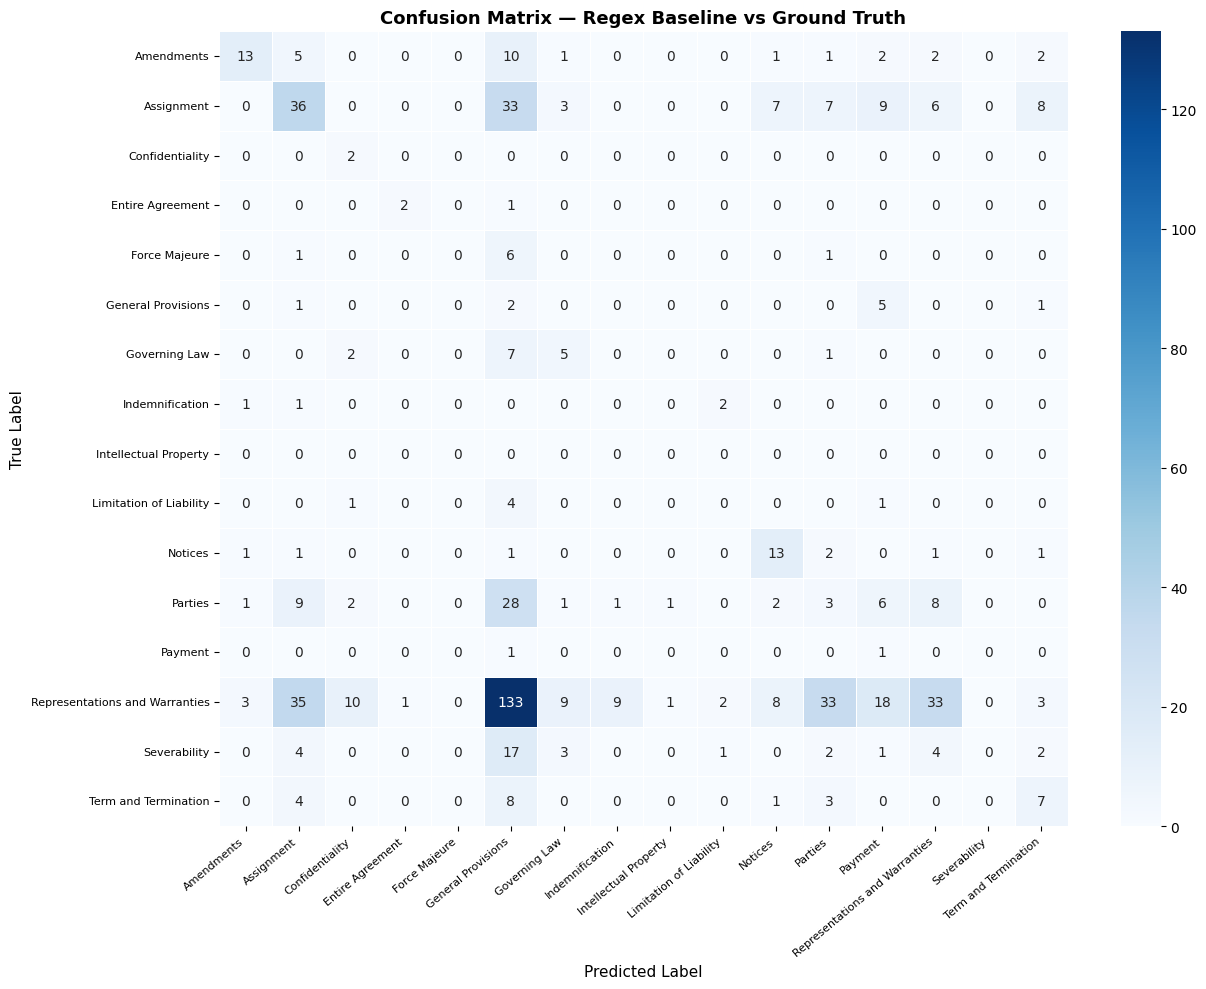

In [17]:
# ── Figure 1: Confusion Matrix ────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred, labels=LABELS)
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS, ax=ax, linewidths=0.4)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label',      fontsize=11)
ax.set_title('Confusion Matrix — Regex Baseline vs Ground Truth', fontsize=13, fontweight='bold')
plt.xticks(rotation=40, ha='right', fontsize=8)
plt.yticks(rotation=0,  fontsize=8)
plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR)/'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

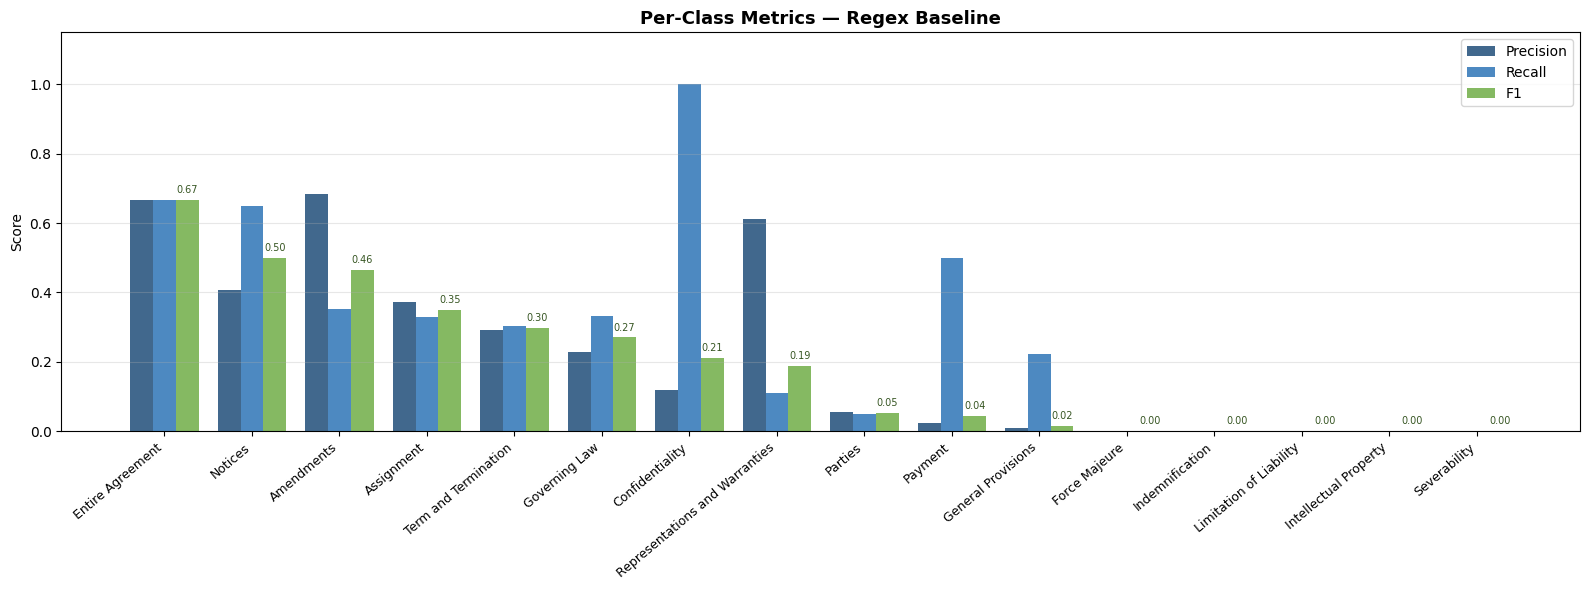

In [18]:
# ── Figure 2: Per-class Precision / Recall / F1 ───────────────────────────────
ls = per_class_df.index.tolist()
x, w = np.arange(len(ls)), 0.26
fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x-w,  per_class_df['Precision'], w, label='Precision', color='#1f4e79', alpha=0.85)
ax.bar(x,    per_class_df['Recall'],    w, label='Recall',    color='#2e75b6', alpha=0.85)
ax.bar(x+w,  per_class_df['F1'],        w, label='F1',        color='#70ad47', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(ls, rotation=40, ha='right', fontsize=9)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
ax.set_title('Per-Class Metrics — Regex Baseline', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for xi, f1 in zip(x, per_class_df['F1']):
    ax.text(xi+w, f1+0.02, f'{f1:.2f}', ha='center', fontsize=7, color='#375623')
plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR)/'per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

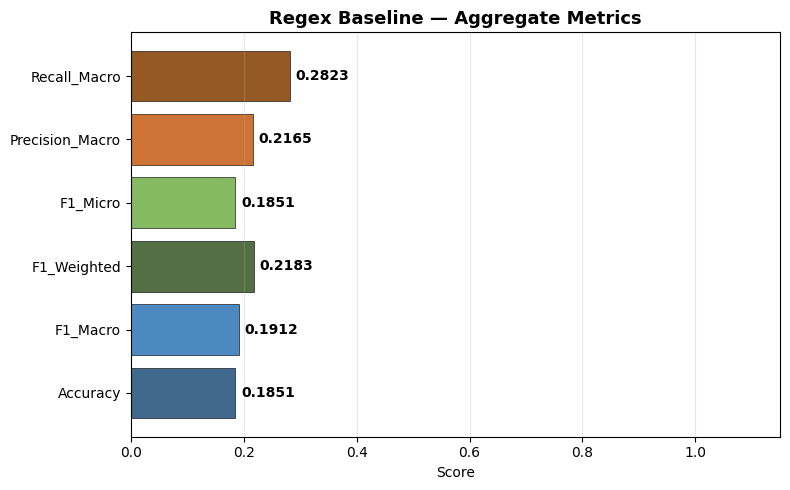

In [19]:
# ── Figure 3: Aggregate metrics ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(list(metrics.keys()), list(metrics.values()),
               color=['#1f4e79','#2e75b6','#375623','#70ad47','#c55a11','#833c00'],
               alpha=0.85, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
ax.set_xlim(0, 1.15); ax.set_xlabel('Score')
ax.set_title('Regex Baseline — Aggregate Metrics', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR)/'aggregate_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

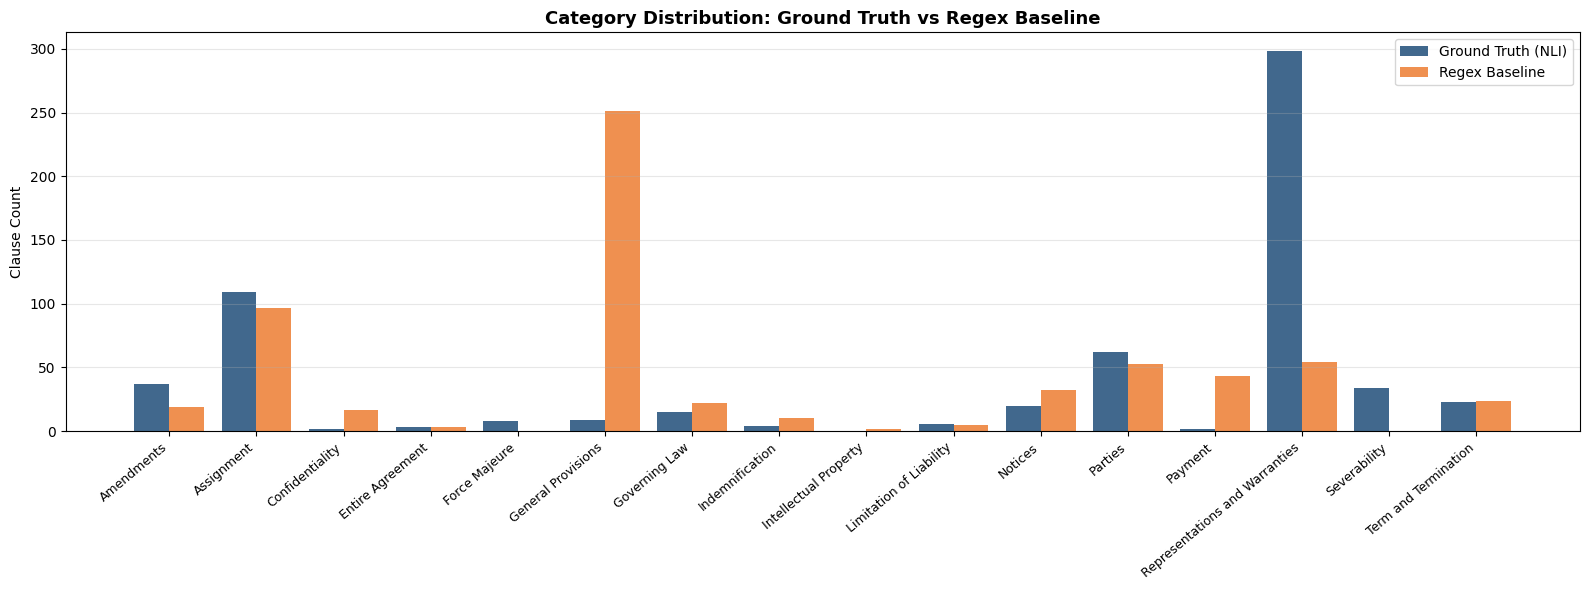

In [20]:
# ── Figure 4: Ground Truth vs Regex label distribution ───────────────────────
all_cats = sorted(set(df['ground_truth']) | set(df['regex_label']))
gt_c     = df['ground_truth'].value_counts()
rx_c     = df['regex_label'].value_counts()
x, w     = np.arange(len(all_cats)), 0.40
fig, ax  = plt.subplots(figsize=(16, 6))
ax.bar(x-w/2, [gt_c.get(c,0) for c in all_cats], w, label='Ground Truth (NLI)', color='#1f4e79', alpha=0.85)
ax.bar(x+w/2, [rx_c.get(c,0) for c in all_cats], w, label='Regex Baseline',     color='#ed7d31', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(all_cats, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Clause Count')
ax.set_title('Category Distribution: Ground Truth vs Regex Baseline', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR)/'category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Export Results

In [21]:
df[['source_file','clause_id','clause_text',
    'week2_category','regex_label','ground_truth']].to_csv(
    Path(OUTPUT_DIR)/'regex_baseline_results.csv', index=False)
per_class_df.to_csv(Path(OUTPUT_DIR)/'per_class_metrics.csv')
json.dump(metrics, open(Path(OUTPUT_DIR)/'aggregate_metrics.json','w'), indent=4)

best  = per_class_df['F1'].idxmax()
worst = per_class_df[per_class_df['Support']>0]['F1'].idxmin()
print('\n' + '='*60)
print('  REGEX BASELINE — FINAL SUMMARY')
print('='*60)
print(f'  PDFs processed           : {len(pdf_files)}')
print(f'  Clauses evaluated        : {len(df)}')
print(f'  Unique categories        : {len(LABELS)}')
print()
for k, v in metrics.items():
    print(f'  {k:22s}: {v:.4f}')
print()
print(f'  Best  classified : {best}  (F1={per_class_df.loc[best,"F1"]:.4f})')
print(f'  Worst classified : {worst}  (F1={per_class_df.loc[worst,"F1"]:.4f})')
print('='*60)
print('\nOutput files:')
for fn in ['corpus_clauses.json','ground_truth_labels.json',
           'regex_baseline_results.csv','per_class_metrics.csv',
           'aggregate_metrics.json','confusion_matrix.png',
           'per_class_metrics.png','aggregate_metrics.png',
           'category_distribution.png']:
    ok = '✓' if (Path(OUTPUT_DIR)/fn).exists() else '–'
    print(f'  [{ok}] {fn}')


  REGEX BASELINE — FINAL SUMMARY
  PDFs processed           : 5
  Clauses evaluated        : 632
  Unique categories        : 16

  Accuracy              : 0.1851
  F1_Macro              : 0.1912
  F1_Weighted           : 0.2183
  F1_Micro              : 0.1851
  Precision_Macro       : 0.2165
  Recall_Macro          : 0.2823

  Best  classified : Entire Agreement  (F1=0.6667)
  Worst classified : Force Majeure  (F1=0.0000)

Output files:
  [✓] corpus_clauses.json
  [✓] ground_truth_labels.json
  [✓] regex_baseline_results.csv
  [✓] per_class_metrics.csv
  [✓] aggregate_metrics.json
  [✓] confusion_matrix.png
  [✓] per_class_metrics.png
  [✓] aggregate_metrics.png
  [✓] category_distribution.png
